# AI/ML Malaria Risk Prediction Model

This notebook builds a supervised machine learning model using the malaria dataset prepared from the PDFs.

## Main Goal

Predict whether a state/UT will be **high malaria risk in the next year** using only information available before that year.

## What This Model Can Do

- Learn from past malaria burden and case-rate patterns.
- Compare multiple AI/ML models against a baseline model.
- Evaluate predictions on later years that were not used for training.
- Estimate next-year risk probability for each state/UT.
- Highlight the project regions: Odisha, Mizoram, and Tripura.

## Important Limitation

This is a risk prediction model, not a causal model. It does not directly know rainfall, temperature, mosquito density, interventions, sanitation, or migration. It predicts from historical malaria patterns already present in the dataset.

## 0. Setup

Run the install cell only if the notebook kernel is missing packages.

In [1]:
# Uncomment and run this cell if packages are missing.
# %pip install pandas numpy matplotlib scikit-learn

**Why this matters:** The model needs common data-science libraries for loading CSV files, plotting trends, training classifiers, and calculating evaluation metrics. Keeping the install command separate avoids reinstalling packages every time the notebook runs.

In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

ANALYSIS_READY_DIR = PROJECT_ROOT / "data" / "analysis_ready"
STATE_YEAR_CSV = ANALYSIS_READY_DIR / "state_year_malaria_clean.csv"
AIML_FEATURES_CSV = ANALYSIS_READY_DIR / "aiml_state_year_features.csv"

SELECTED_REGIONS = ["Odisha", "Mizoram", "Tripura"]
RANDOM_STATE = 42

HIGHLIGHT_COLORS = {
    "Odisha": "#1f77b4",
    "Mizoram": "#ff7f0e",
    "Tripura": "#2ca02c",
}

def fmt_probability(value):
    return f"{value:.1%}"

def risk_band(probability):
    if probability >= 0.70:
        return "High"
    if probability >= 0.40:
        return "Moderate"
    return "Low"

**Why this matters:** This cell defines the project paths, selected regions, plotting style, and helper functions in one place. That keeps every later table and graph consistent and makes the notebook easier to rerun on another computer.

## 1. Load the Analysis-Ready Data

We use two prepared CSV files:

- `state_year_malaria_clean.csv`: state-level yearly malaria burden.
- `aiml_state_year_features.csv`: lagged features and next-year outcomes for machine learning.

In [3]:
state_year = pd.read_csv(STATE_YEAR_CSV)
model_df = pd.read_csv(AIML_FEATURES_CSV)

state_numeric_cols = [
    "year",
    "total_cases",
    "total_deaths",
    "district_count",
    "population_2011",
    "cases_per_100k",
    "deaths_per_100k",
]
for col in state_numeric_cols:
    state_year[col] = pd.to_numeric(state_year[col], errors="coerce")

model_numeric_cols = [col for col in model_df.columns if col not in {"state", "selected_region"}]
for col in model_numeric_cols:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

display(state_year.head())
display(model_df.head())

print("State-year rows:", len(state_year))
print("Feature rows:", len(model_df))
print("States/UTs:", state_year["state"].nunique())
print("State-year range:", int(state_year["year"].min()), "-", int(state_year["year"].max()))
print("Feature-year range:", int(model_df["year"].min()), "-", int(model_df["year"].max()))

,year,state,total_cases,total_deaths,district_count,population_2011,cases_per_100k,deaths_per_100k,selected_region
0,2000,Andaman And Nicobar Islands,1990,5,4,380581,522.884747,1.313781,no
1,2000,Andhra Pradesh,80557,6,23,49577103,162.488316,0.012102,no
2,2000,Arunachal Pradesh,46165,0,12,1383727,3336.279483,0.000000,no
3,2000,Assam,84915,43,23,31205576,272.114830,0.137796,no
4,2000,Bihar,9509,2,37,104099452,9.134534,0.001921,no


,state,year,population_2011,district_count,total_cases,cases_per_100k,total_cases_lag1,total_cases_lag2,total_cases_lag3,total_deaths_lag1,...,cases_per_100k_lag2,cases_per_100k_lag3,deaths_per_100k_lag1,cases_rate_roll3,cases_yoy_change,rate_yoy_change,next_year_cases,next_year_rate,high_risk_next_year,selected_region
0,Andaman And Nicobar Islands,2003,380581,1,427,112.196878,1557,434,1990,4,...,114.036171,522.884747,1.051025,348.677417,-0.725755,-0.725755,1800,472.961078,1,no
1,Andaman And Nicobar Islands,2004,380581,4,1800,472.961078,427,1557,434,0,...,409.111332,114.036171,0.000000,211.781460,3.215457,3.215457,3234,849.753403,1,no
2,Andaman And Nicobar Islands,2005,380581,1,3234,849.753403,1800,427,1557,4,...,112.196878,409.111332,1.051025,331.423096,0.796667,0.796667,18866,4957.157609,1,no
3,Andaman And Nicobar Islands,2006,380581,7,18866,4957.157609,3234,1800,427,0,...,472.961078,112.196878,0.000000,478.303786,4.833643,4.833643,29938,7866.393751,1,no
4,Andaman And Nicobar Islands,2008,380581,8,29938,7866.393751,18866,3234,1800,22,...,849.753403,472.961078,5.780635,2093.290697,0.586876,0.586876,22081,5801.918645,1,no


State-year rows: 858
Feature rows: 706
States/UTs: 38
State-year range: 2000 - 2024
Feature-year range: 2003 - 2023


**Why this matters:** The model depends on clean numeric columns. This cell confirms that the files load correctly and shows the exact number of rows, states, and years available before we train anything.

## 2. Inspect the Project Regions

The AI/ML model is trained on all available states/UTs, but Odisha, Mizoram, and Tripura are kept visible because they are the main project regions.

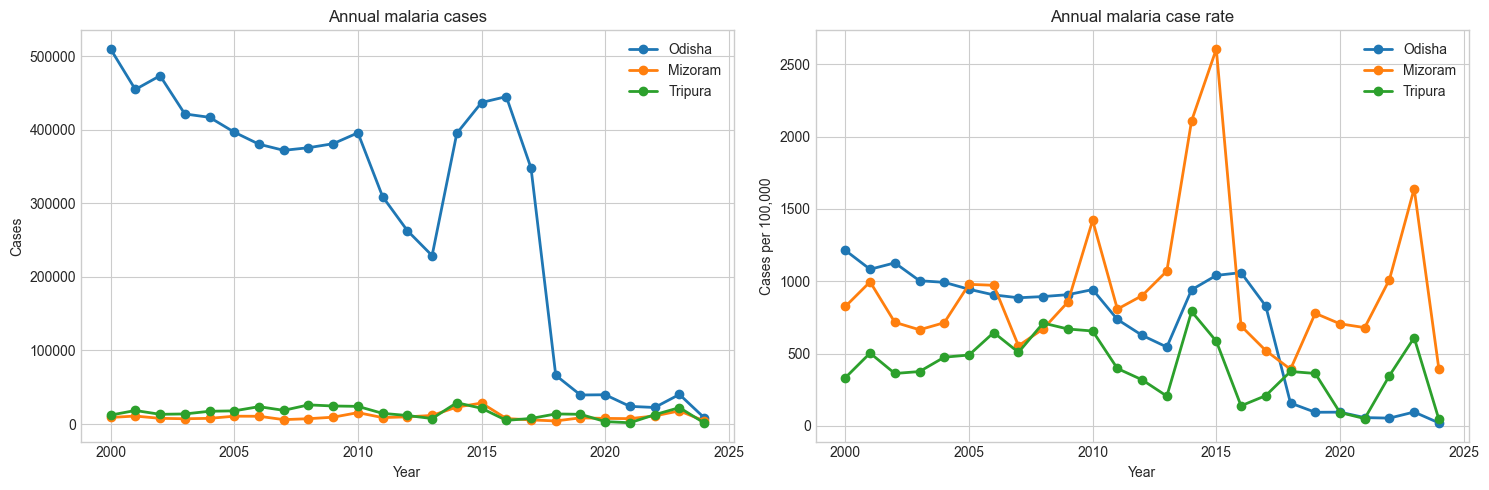

,year,state,total_cases,total_deaths,district_count,population_2011,cases_per_100k,deaths_per_100k,selected_region
477,2013,Tripura,7560,7,10,3673917,205.774926,0.190532,yes
512,2014,Tripura,29064,42,6,3673917,791.090272,1.143194,yes
546,2015,Tripura,21509,8,6,3673917,585.451441,0.217751,yes
581,2016,Tripura,5104,6,6,3673917,138.925294,0.163313,yes
615,2017,Tripura,7692,6,12,3673917,209.367822,0.163313,yes
651,2018,Tripura,13823,13,12,3673917,376.246932,0.353846,yes
685,2019,Tripura,13322,1,12,3673917,362.610260,0.027219,yes
720,2020,Tripura,3395,2,8,3673917,92.408185,0.054438,yes
752,2021,Tripura,1862,1,6,3673917,50.681602,0.027219,yes
786,2022,Tripura,12771,3,8,3673917,347.612643,0.081657,yes


In [4]:
selected = state_year[state_year["state"].isin(SELECTED_REGIONS)].copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for region in SELECTED_REGIONS:
    region_df = selected[selected["state"] == region]
    axes[0].plot(
        region_df["year"],
        region_df["total_cases"],
        marker="o",
        linewidth=2,
        label=region,
        color=HIGHLIGHT_COLORS[region],
    )
    axes[1].plot(
        region_df["year"],
        region_df["cases_per_100k"],
        marker="o",
        linewidth=2,
        label=region,
        color=HIGHLIGHT_COLORS[region],
    )

axes[0].set_title("Annual malaria cases")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Cases")
axes[0].legend()

axes[1].set_title("Annual malaria case rate")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Cases per 100,000")
axes[1].legend()

plt.tight_layout()
plt.show()

display(selected.sort_values(["state", "year"]).tail(12))

**Why this matters:** These plots show whether the selected regions have similar or contrasting epidemic histories. That matters because an ML model trained across all states must still make sensible predictions for the specific regions used in the report.

## 3. Define the Prediction Target

We predict:

> Will this state/UT be high malaria risk next year?

A state/UT is labelled **high risk** if its next-year malaria case rate is in the top 25% of the training-period observations.

In [5]:
feature_cols = [
    "year",
    "population_2011",
    "district_count",
    "total_cases_lag1",
    "total_cases_lag2",
    "total_cases_lag3",
    "total_deaths_lag1",
    "cases_per_100k_lag1",
    "cases_per_100k_lag2",
    "cases_per_100k_lag3",
    "deaths_per_100k_lag1",
    "cases_rate_roll3",
    "cases_yoy_change",
    "rate_yoy_change",
]

model_df = model_df.dropna(subset=feature_cols + ["next_year_rate"]).copy()

train_period_for_threshold = model_df[model_df["year"] <= 2016]
risk_threshold = train_period_for_threshold["next_year_rate"].quantile(0.75)

model_df["risk_target"] = (model_df["next_year_rate"] >= risk_threshold).astype(int)
model_df["prediction_year"] = model_df["year"] + 1

print("High-risk threshold:", round(risk_threshold, 2), "cases per 100,000")
print("High-risk share:", round(model_df["risk_target"].mean(), 3))

display(
    model_df[
        [
            "state",
            "year",
            "prediction_year",
            "cases_per_100k",
            "next_year_rate",
            "risk_target",
        ]
    ].head(10)
)

High-risk threshold: 356.85 cases per 100,000
High-risk share: 0.187


,state,year,prediction_year,cases_per_100k,next_year_rate,risk_target
0,Andaman And Nicobar Islands,2003,2004,112.196878,472.961078,1
1,Andaman And Nicobar Islands,2004,2005,472.961078,849.753403,1
2,Andaman And Nicobar Islands,2005,2006,849.753403,4957.157609,1
3,Andaman And Nicobar Islands,2006,2007,4957.157609,7866.393751,1
4,Andaman And Nicobar Islands,2008,2009,7866.393751,5801.918645,1
5,Andaman And Nicobar Islands,2010,2011,5801.918645,4038.562093,1
6,Andaman And Nicobar Islands,2012,2013,4038.562093,2352.981363,1
7,Andaman And Nicobar Islands,2014,2015,2352.981363,1727.884471,1
8,Andaman And Nicobar Islands,2016,2017,1727.884471,1271.477031,1
9,Andaman And Nicobar Islands,2018,2019,1271.477031,79.089602,0


**Why this matters:** The model needs a clear outcome variable. Using a training-period threshold avoids defining “high risk” with information from the future test period, which would make the evaluation too optimistic.

## 4. Chronological Train, Validation, and Test Split

We split by time:

- Training: feature years up to 2016
- Validation: feature years 2017 to 2019
- Test: feature years 2020 onward

Each feature year predicts the following year.

In [6]:
train = model_df[model_df["year"] <= 2016].copy()
validation = model_df[(model_df["year"] >= 2017) & (model_df["year"] <= 2019)].copy()
test = model_df[model_df["year"] >= 2020].copy()

X_train = train[feature_cols]
y_train = train["risk_target"]

X_val = validation[feature_cols]
y_val = validation["risk_target"]

X_test = test[feature_cols]
y_test = test["risk_target"]

split_summary = pd.DataFrame(
    [
        {"split": "train", "rows": len(train), "year_min": train["year"].min(), "year_max": train["year"].max(), "high_risk_rate": y_train.mean()},
        {"split": "validation", "rows": len(validation), "year_min": validation["year"].min(), "year_max": validation["year"].max(), "high_risk_rate": y_val.mean()},
        {"split": "test", "rows": len(test), "year_min": test["year"].min(), "year_max": test["year"].max(), "high_risk_rate": y_test.mean()},
    ]
)

display(split_summary)

,split,rows,year_min,year_max,high_risk_rate
0,train,472,2003,2016,0.250000
1,validation,102,2017,2019,0.058824
2,test,126,2020,2023,0.055556


**Why this matters:** Epidemic prediction is a forecasting task, so time order matters. A chronological split tests whether the model can generalize to later years instead of memorizing random rows from the same time period.

## 5. Train Candidate AI/ML Models

We compare simple and stronger classifiers:

- Dummy baseline
- Logistic Regression
- Random Forest
- Gradient Boosting

In [7]:
candidate_models = {
    "Dummy baseline": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
        ]
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        min_samples_leaf=3,
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

validation_results = []
fitted_candidates = {}

for name, model in candidate_models.items():
    fitted = clone(model)
    fitted.fit(X_train, y_train)
    fitted_candidates[name] = fitted

    val_pred = fitted.predict(X_val)
    val_prob = fitted.predict_proba(X_val)[:, 1] if hasattr(fitted, "predict_proba") else val_pred

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_val, val_pred, average="binary", zero_division=0
    )

    validation_results.append(
        {
            "model": name,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "balanced_accuracy": balanced_accuracy_score(y_val, val_pred),
            "roc_auc": roc_auc_score(y_val, val_prob) if len(set(y_val)) > 1 else np.nan,
            "average_precision": average_precision_score(y_val, val_prob) if len(set(y_val)) > 1 else np.nan,
        }
    )

validation_results_df = (
    pd.DataFrame(validation_results)
    .sort_values(["f1", "average_precision", "balanced_accuracy"], ascending=False)
    .reset_index(drop=True)
)

display(validation_results_df)

,model,precision,recall,f1,balanced_accuracy,roc_auc,average_precision
0,Random Forest,0.357143,0.833333,0.500000,0.869792,0.932292,0.332326
1,Gradient Boosting,0.333333,0.500000,0.400000,0.718750,0.923611,0.303482
2,Logistic Regression,0.250000,0.500000,0.333333,0.703125,0.913194,0.294853
3,Dummy baseline,0.000000,0.000000,0.000000,0.500000,0.500000,0.058824


**Why this matters:** The dummy model shows what happens if we do almost no learning. The real ML models must beat that baseline; otherwise the features are not adding useful predictive signal.

## 6. Select the Best Model and Evaluate on the Test Period

The best model is selected on validation performance, then retrained on training plus validation data and evaluated once on the held-out test period.

Selected model: Random Forest

               precision    recall  f1-score   support

not high risk       0.99      1.00      1.00       119
    high risk       1.00      0.86      0.92         7

     accuracy                           0.99       126
    macro avg       1.00      0.93      0.96       126
 weighted avg       0.99      0.99      0.99       126



,balanced_accuracy,roc_auc,average_precision
0,0.928571,0.996399,0.957143


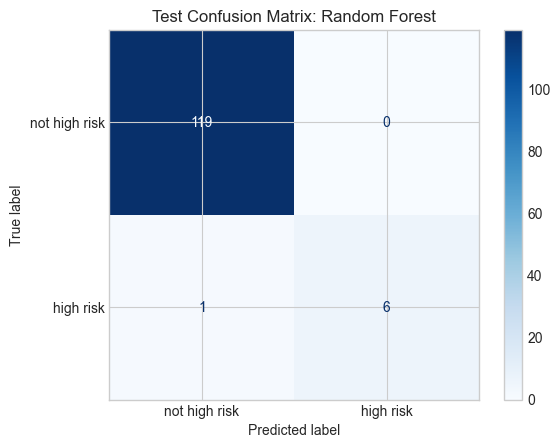

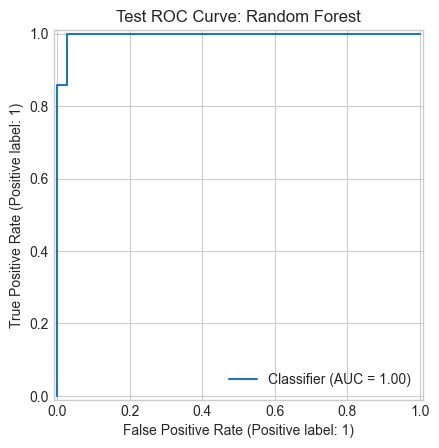

In [8]:
best_model_name = validation_results_df.iloc[0]["model"]
best_model_template = candidate_models[best_model_name]

train_val = pd.concat([train, validation], ignore_index=True)
X_train_val = train_val[feature_cols]
y_train_val = train_val["risk_target"]

best_model = clone(best_model_template)
best_model.fit(X_train_val, y_train_val)

test_pred = best_model.predict(X_test)
test_prob = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, "predict_proba") else test_pred

print("Selected model:", best_model_name)
print()
print(classification_report(y_test, test_pred, target_names=["not high risk", "high risk"], zero_division=0))

test_metrics = {
    "balanced_accuracy": balanced_accuracy_score(y_test, test_pred),
    "roc_auc": roc_auc_score(y_test, test_prob) if len(set(y_test)) > 1 else np.nan,
    "average_precision": average_precision_score(y_test, test_prob) if len(set(y_test)) > 1 else np.nan,
}
display(pd.DataFrame([test_metrics]))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, test_pred),
    display_labels=["not high risk", "high risk"],
).plot(cmap="Blues")
plt.title(f"Test Confusion Matrix: {best_model_name}")
plt.show()

if len(set(y_test)) > 1:
    RocCurveDisplay.from_predictions(y_test, test_prob)
    plt.title(f"Test ROC Curve: {best_model_name}")
    plt.show()

**Why this matters:** The test period is the honest check. It tells us how well the chosen model performs on later years that were not used for model selection.

## 7. Understand Which Features Drive Prediction

Feature importance helps explain what the risk model is using.

,feature,importance
0,cases_per_100k_lag1,0.218811
1,cases_rate_roll3,0.202250
2,cases_per_100k_lag3,0.176394
3,cases_per_100k_lag2,0.140654
4,deaths_per_100k_lag1,0.056626
5,population_2011,0.036548
6,cases_yoy_change,0.027164
7,rate_yoy_change,0.026988
8,total_cases_lag1,0.021914
9,total_cases_lag3,0.020293


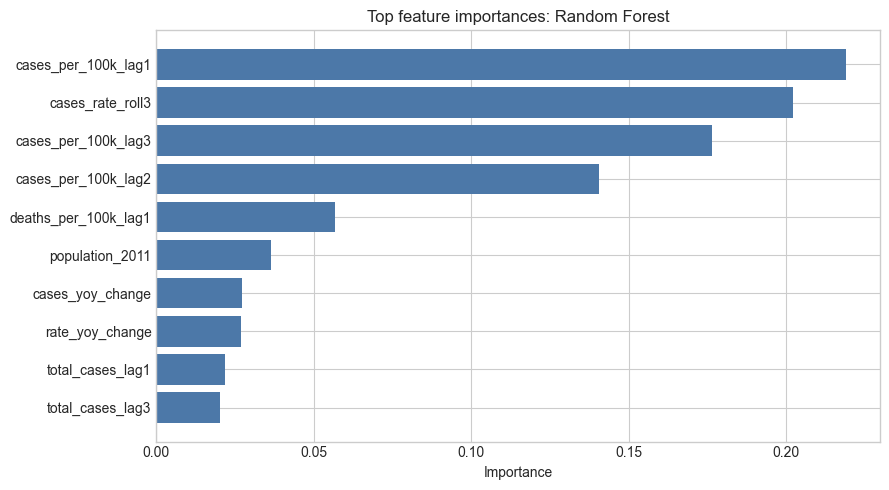

In [9]:
if best_model_name in {"Random Forest", "Gradient Boosting"}:
    importance_values = best_model.feature_importances_
elif best_model_name == "Logistic Regression":
    importance_values = np.abs(best_model.named_steps["model"].coef_[0])
else:
    importance_values = np.zeros(len(feature_cols))

importance_df = (
    pd.DataFrame({"feature": feature_cols, "importance": importance_values})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(importance_df)

fig, ax = plt.subplots(figsize=(9, 5))
top_importance = importance_df.head(10).sort_values("importance")
ax.barh(top_importance["feature"], top_importance["importance"], color="#4c78a8")
ax.set_title(f"Top feature importances: {best_model_name}")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

**Why this matters:** A prediction alone is not enough for a report. Feature importance shows whether the model is mainly using recent case rates, older lags, deaths, population, or trend changes.

## 8. Historical Risk Predictions for Selected Regions

These are test-period predictions for Odisha, Mizoram, and Tripura.

,state,year,prediction_year,cases_per_100k,next_year_rate,risk_target,predicted_high_risk,predicted_high_risk_probability,risk_band
462,Mizoram,2020,2021,706.157276,679.635365,1,1,0.699546,Moderate
463,Mizoram,2021,2022,679.635365,1011.660527,1,1,0.754112,High
464,Mizoram,2022,2023,1011.660527,1640.530584,1,1,0.826984,High
465,Mizoram,2023,2024,1640.530584,392.633653,1,1,0.832773,High
504,Odisha,2020,2021,95.020234,57.435257,0,0,0.361256,Low
505,Odisha,2021,2022,57.435257,53.818751,0,0,0.001289,Low
506,Odisha,2022,2023,53.818751,96.011318,0,0,0.002000,Low
507,Odisha,2023,2024,96.011318,20.827071,0,0,0.040655,Low
630,Tripura,2020,2021,92.408185,50.681602,0,0,0.184054,Low
631,Tripura,2021,2022,50.681602,347.612643,0,0,0.105669,Low


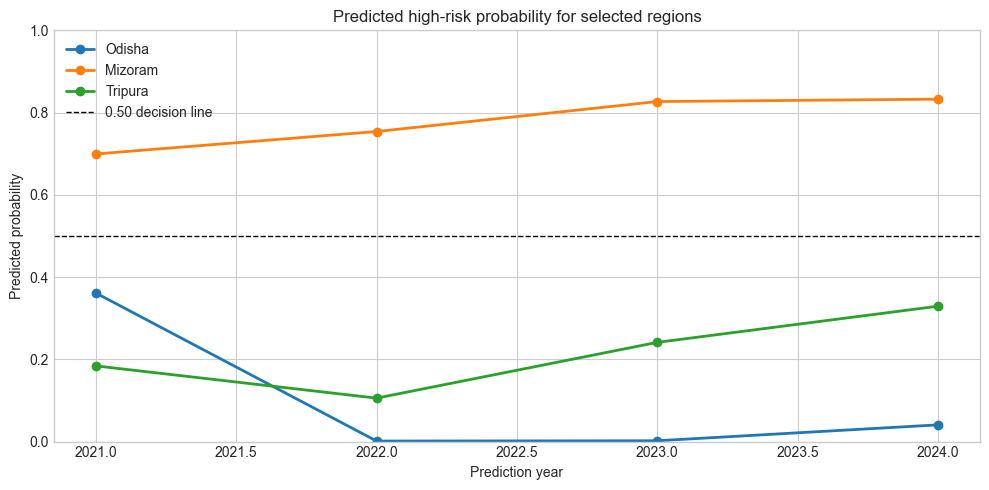

In [10]:
historical_predictions = test.copy()
historical_predictions["predicted_high_risk"] = test_pred
historical_predictions["predicted_high_risk_probability"] = test_prob
historical_predictions["risk_band"] = historical_predictions["predicted_high_risk_probability"].apply(risk_band)

selected_historical_predictions = historical_predictions[
    historical_predictions["state"].isin(SELECTED_REGIONS)
][
    [
        "state",
        "year",
        "prediction_year",
        "cases_per_100k",
        "next_year_rate",
        "risk_target",
        "predicted_high_risk",
        "predicted_high_risk_probability",
        "risk_band",
    ]
].sort_values(["state", "year"])

display(selected_historical_predictions)

fig, ax = plt.subplots(figsize=(10, 5))
for region in SELECTED_REGIONS:
    region_df = selected_historical_predictions[selected_historical_predictions["state"] == region]
    ax.plot(
        region_df["prediction_year"],
        region_df["predicted_high_risk_probability"],
        marker="o",
        linewidth=2,
        label=region,
        color=HIGHLIGHT_COLORS[region],
    )

ax.axhline(0.5, color="black", linestyle="--", linewidth=1, label="0.50 decision line")
ax.set_title("Predicted high-risk probability for selected regions")
ax.set_xlabel("Prediction year")
ax.set_ylabel("Predicted probability")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

**Why this matters:** This connects the ML model back to the chosen project regions. It shows not only whether the model predicts high risk, but also how confident the model is over the held-out years.

## 9. Build Latest-Year Features for 2025 Risk Scoring

The labelled AI/ML file ends at feature year 2023 because it needs a known next year. To score 2025 risk, we create the same lagged features from the latest available state-year data.

In [11]:
def build_latest_feature_rows(state_year_df):
    rows = []
    for state, group in state_year_df.dropna(subset=["population_2011"]).groupby("state"):
        group = group.sort_values("year").reset_index(drop=True)
        if len(group) < 4:
            continue

        current = group.iloc[-1]
        lag1 = group.iloc[-2]
        lag2 = group.iloc[-3]
        lag3 = group.iloc[-4]

        current_cases = current["total_cases"]
        previous_cases = lag1["total_cases"]
        current_rate = current["cases_per_100k"]
        previous_rate = lag1["cases_per_100k"]

        rows.append(
            {
                "state": state,
                "year": current["year"],
                "prediction_year": current["year"] + 1,
                "population_2011": current["population_2011"],
                "district_count": current["district_count"],
                "total_cases": current["total_cases"],
                "cases_per_100k": current["cases_per_100k"],
                "total_cases_lag1": lag1["total_cases"],
                "total_cases_lag2": lag2["total_cases"],
                "total_cases_lag3": lag3["total_cases"],
                "total_deaths_lag1": lag1["total_deaths"],
                "cases_per_100k_lag1": lag1["cases_per_100k"],
                "cases_per_100k_lag2": lag2["cases_per_100k"],
                "cases_per_100k_lag3": lag3["cases_per_100k"],
                "deaths_per_100k_lag1": lag1["deaths_per_100k"],
                "cases_rate_roll3": np.nanmean(
                    [
                        lag1["cases_per_100k"],
                        lag2["cases_per_100k"],
                        lag3["cases_per_100k"],
                    ]
                ),
                "cases_yoy_change": (current_cases - previous_cases) / previous_cases if previous_cases > 0 else np.nan,
                "rate_yoy_change": (current_rate - previous_rate) / previous_rate if previous_rate > 0 else np.nan,
            }
        )
    return pd.DataFrame(rows)

latest_features = build_latest_feature_rows(state_year)
latest_features = latest_features.dropna(subset=feature_cols).copy()

display(latest_features[["state", "year", "prediction_year", "total_cases", "cases_per_100k"]].head())
print("Latest feature year:", int(latest_features["year"].max()))
print("Prediction year:", int(latest_features["prediction_year"].max()))
print("Rows available for scoring:", len(latest_features))

,state,year,prediction_year,total_cases,cases_per_100k
0,Andaman And Nicobar Islands,2024,2025,2846,747.804015
1,Andhra Pradesh,2024,2025,407,0.820943
2,Arunachal Pradesh,2024,2025,2,0.144537
3,Assam,2024,2025,95,0.304433
4,Bihar,2024,2025,147,0.141211


Latest feature year: 2024
Prediction year: 2025
Rows available for scoring: 37


**Why this matters:** This turns the trained model into an actual risk prediction tool. Instead of only evaluating old predictions, we use the most recent available malaria history to estimate next-year risk.

## 10. Predict 2025 High-Risk Probability

The final model is trained on all labelled historical rows, then used to score the latest available feature rows.

In [12]:
final_model = clone(best_model_template)
final_model.fit(model_df[feature_cols], model_df["risk_target"])

latest_features["predicted_high_risk"] = final_model.predict(latest_features[feature_cols])
latest_features["predicted_high_risk_probability"] = (
    final_model.predict_proba(latest_features[feature_cols])[:, 1]
    if hasattr(final_model, "predict_proba")
    else latest_features["predicted_high_risk"]
)
latest_features["risk_band"] = latest_features["predicted_high_risk_probability"].apply(risk_band)

latest_risk_table = latest_features[
    [
        "state",
        "year",
        "prediction_year",
        "total_cases",
        "cases_per_100k",
        "predicted_high_risk",
        "predicted_high_risk_probability",
        "risk_band",
    ]
].sort_values("predicted_high_risk_probability", ascending=False)

print("Top predicted high-risk states/UTs:")
display(latest_risk_table.head(20))

print("Selected project regions:")
display(latest_risk_table[latest_risk_table["state"].isin(SELECTED_REGIONS)].sort_values("state"))

Top predicted high-risk states/UTs:


,state,year,prediction_year,total_cases,cases_per_100k,predicted_high_risk,predicted_high_risk_probability,risk_band
0,Andaman And Nicobar Islands,2024,2025,2846,747.804015,1,0.764083,High
24,Mizoram,2024,2025,4308,392.633653,1,0.744557,High
7,D & N Haveli,2019,2020,681,198.132723,1,0.607802,Moderate
33,The Dadra And Nagar Haveli And Daman And Diu,2024,2025,23,3.918522,0,0.427750,Moderate
34,Tripura,2024,2025,1662,45.237821,0,0.249384,Low
5,Chandigarh,2022,2023,329,31.171538,0,0.181798,Low
18,Ladakh,2024,2025,1,0.364579,0,0.150369,Low
23,Meghalaya,2024,2025,121,4.078346,0,0.125135,Low
27,Puducherry,2024,2025,96,7.692597,0,0.094401,Low
30,Sikkim,2024,2025,0,0.000000,0,0.056255,Low


Selected project regions:


,state,year,prediction_year,total_cases,cases_per_100k,predicted_high_risk,predicted_high_risk_probability,risk_band
24,Mizoram,2024,2025,4308,392.633653,1,0.744557,High
26,Odisha,2024,2025,8742,20.827071,0,0.003735,Low
34,Tripura,2024,2025,1662,45.237821,0,0.249384,Low


**Why this matters:** This is the main risk prediction output. The probability column is more informative than only a yes/no label because it lets us compare states by relative predicted risk.

## 11. Visualize the Highest Predicted Risks

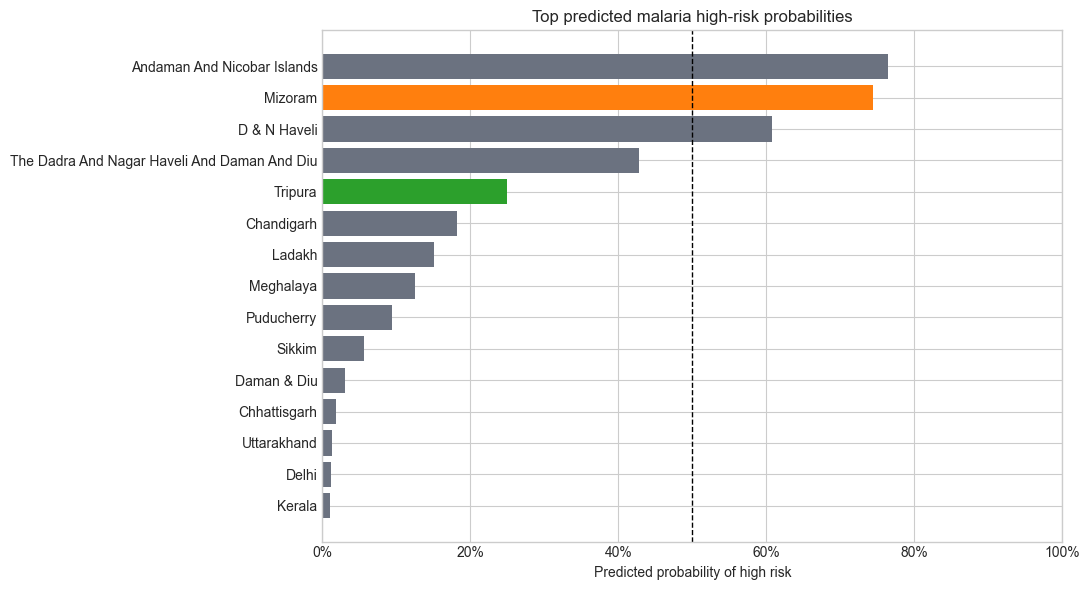

In [13]:
top_latest = latest_risk_table.head(15).copy()
colors = [HIGHLIGHT_COLORS.get(state, "#6b7280") for state in top_latest["state"]]

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(
    top_latest["state"][::-1],
    top_latest["predicted_high_risk_probability"][::-1],
    color=colors[::-1],
)
ax.axvline(0.5, color="black", linestyle="--", linewidth=1)
ax.set_title("Top predicted malaria high-risk probabilities")
ax.set_xlabel("Predicted probability of high risk")
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
plt.tight_layout()
plt.show()

**Why this matters:** The bar chart makes the risk ranking easy to communicate in the final report. It also shows whether the selected regions appear among the highest predicted risks nationally.

## 12. Interpretation for the Report

Use these points when writing the AI/ML section:

- The target is next-year high malaria risk, defined by a training-period case-rate threshold.
- The model uses lagged malaria indicators, rolling averages, and recent trend changes.
- The chronological split makes the evaluation closer to real forecasting.
- The final risk table gives predicted probability, not just a yes/no class.
- The model can identify risk patterns, but it cannot prove causes because environmental and socioeconomic variables are not included.

## Biological Assumptions Not Included

This AI/ML model does not explicitly model mosquito dynamics, rainfall, temperature, immunity, interventions, or human movement. Those factors may explain why risk differs between regions, but they are not present in the current CSV files.